# Modeling 30-Day Readmission Risk

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

from xgboost import XGBClassifier

df = pd.read_csv("../data/diabetes_clean.csv")

## Feature Selection

Selecting demographic, clinical, and utilization variables as predictors.

## Baseline Model: Logistic Regression

A baseline model is trained to establish initial performance. Logistic Regression is used to 

### First Iteration with Logistic Regression, less features

In [10]:
X = df[[
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]]

y = df["readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6302717887305351
              precision    recall  f1-score   support

           0       0.91      0.73      0.81     18083
           1       0.17      0.45      0.25      2271

    accuracy                           0.70     20354
   macro avg       0.54      0.59      0.53     20354
weighted avg       0.83      0.70      0.75     20354



### Second Iteration with Logistic Regression, slightly more features

In [12]:
X = df[
    [
        "time_in_hospital",
        "num_lab_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "age",
        "gender"
    ]
]

X = pd.get_dummies(X, drop_first=True)
y = df["readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6389229170360371
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18083
           1       0.17      0.47      0.25      2271

    accuracy                           0.69     20354
   macro avg       0.54      0.59      0.53     20354
weighted avg       0.83      0.69      0.74     20354



### Third Iteration with Logistic Regression, more features and slight increase to ROC-AUC

In [14]:
X = df[
    [
        "time_in_hospital",
        "num_lab_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "age",
        "gender",
        "A1Cresult",
        "max_glu_serum",
        "insulin",
        "change",
        "diabetesMed"
    ]
]

X = pd.get_dummies(X, drop_first=True)

# clean column names
X.columns = (
    X.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt_", regex=False)
    .str.replace(">", "gt_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_", regex=False)
)

y = df["readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6394531424925912
              precision    recall  f1-score   support

           0       0.92      0.70      0.80     18083
           1       0.17      0.49      0.25      2271

    accuracy                           0.68     20354
   macro avg       0.54      0.59      0.52     20354
weighted avg       0.83      0.68      0.74     20354



## Improved Model: XGBoost

A tree-based model is used to capture nonlinear relationships.

In [15]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.644697466618345
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.54      0.25      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354



## Threshold Tuning

Lowering the classification threshold increases recall at the cost of precision.

In [16]:
for t in [0.5, 0.4, 0.3]:
    y_pred = (y_proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.54      0.25      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.30      0.45     18083
           1       0.13      0.85      0.23      2271

    accuracy                           0.36     20354
   macro avg       0.54      0.57      0.34     20354
weighted avg       0.85      0.36      0.43     20354


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.05      0.10     18083
           1       0.12      0.98      0.21      2271

    accuracy                           0.16     20354
   macro avg       0.54      0.52      0.15     20354
weighted avg       0.87   

## Feature Importance

The model identifies key predictors of readmission risk.

In [17]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
5,number_inpatient,0.289776
25,diabetesMed_Yes,0.061807
13,age_80_90,0.045627
0,time_in_hospital,0.042859
10,age_50_60,0.042578
12,age_70_80,0.038950
8,age_30_40,0.037807
21,insulin_No,0.034366
17,A1Cresult_gt_8,0.031624
4,number_emergency,0.031121


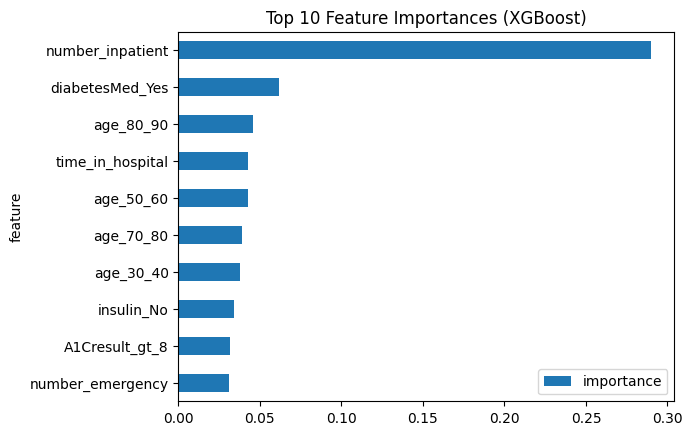

In [19]:
feat_imp.sort_values(by="importance").tail(10).plot(
    kind="barh", x="feature", y="importance"
)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

## ROC Curve

The ROC curve illustrates model discrimination across thresholds.

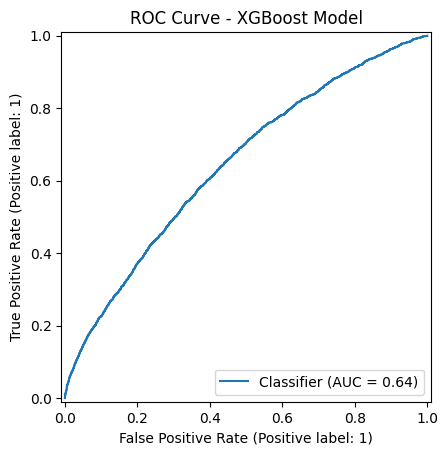

ROC-AUC: 0.645


In [20]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("ROC Curve - XGBoost Model")
plt.show()

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

## Clinical Interpretation

Feature importance analysis from the XGBoost model indicates that prior healthcare utilization is the strongest predictor of 30-day readmission, particularly the number of prior inpatient visits. Clinical variables such as A1C levels and insulin usage also contribute to risk prediction, reflecting disease severity and management. Demographic factors like age further influence risk, suggesting nonlinear effects across age groups. Overall, the model captures a combination of utilization patterns and clinical indicators associated with patient deterioration.

## Conclusion

The model achieves moderate predictive performance (ROC-AUC ~0.64).  
Readmission risk is driven primarily by prior hospital utilization and indicators of disease severity.

Threshold tuning allows adjustment depending on whether recall or precision is prioritized.

Future work could include time-series modeling or incorporation of unstructured clinical data.